# Task 2: Interpolation

This notebook performs interpolation of embedded missing price blocks.

The cleaned price series are produced in `01_data_analysis.ipynb` and loaded from:

`outputs/df_prices_clean.csv`

The goal is to compare two interpolation methods:

1. Brownian log-price bridge
2. Correlation-adjusted ridge bridge

The methods are evaluated using artificial 50-point missing blocks.

In [18]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

OUTPUT_DIR = Path("outputs")
CHART_DIR = Path("charts") / "interpolation"

OUTPUT_DIR.mkdir(exist_ok=True)
CHART_DIR.mkdir(parents=True, exist_ok=True)

In [19]:
df_prices_task2 = pd.read_csv(
    OUTPUT_DIR / "df_prices_clean.csv",
    index_col=0
)

df_prices_task2.index = pd.to_numeric(df_prices_task2.index)

asset_cols = df_prices_task2.columns.tolist()

print("Assets:", asset_cols)
print("\nRemaining missing values:")
display(df_prices_task2.isna().sum())

Assets: ['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity']

Remaining missing values:


gurkor          51
guitars         51
slingshots      51
stocks          51
sugar           51
water           51
tranquillity    51
dtype: int64

## Missing block detection

We define a helper function that identifies consecutive missing intervals. Each missing block is returned as a half-open interval `[start, end)`.

In [20]:
def get_missing(series: pd.Series) -> list[tuple[int, int]]:
    """
    Return missing intervals in a pandas Series.

    Each interval is represented as [start, end), using integer positions.
    """
    mask = series.isna().to_numpy()
    padded = np.concatenate([[False], mask, [False]])
    diff = np.diff(padded.astype(int))

    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0]

    return list(zip(starts, ends))

## Brownian log-price bridge

The baseline interpolation method uses a linear bridge in log-price space. This guarantees consistency with the observed endpoints and keeps reconstructed prices positive after exponentiation.

In [21]:
def brownian_logprice_bridge(
    price_series: pd.Series,
    vol_window: int = 250,
    min_vol_obs: int = 50,
) -> pd.DataFrame:
    #Interpolate embedded missing price blocks using a linear bridge in log-price space.
    #Leading and trailing missing blocks are left unchanged.

    price = price_series.copy()
    log_price = np.log(price)

    filled_log_price = log_price.copy()

    is_missing = price.isna()
    is_interpolated = pd.Series(False, index=price.index)
    uncertainty_log = pd.Series(np.nan, index=price.index)

    returns = log_price.diff()

    for st, ed in get_missing(price):
        gap_len = ed - st

        # Skip leading or trailing gaps
        if st == 0 or ed == len(price):
            continue

        y_left = log_price.iloc[st - 1]
        y_right = log_price.iloc[ed]

        positions = np.arange(1, gap_len + 1)

        bridge_values = (
            y_left
            + positions / (gap_len + 1) * (y_right - y_left)
        )

        filled_log_price.iloc[st:ed] = bridge_values
        is_interpolated.iloc[st:ed] = True

        left_start = max(1, st - vol_window)
        right_end = min(len(price), ed + vol_window)

        local_returns = pd.concat([
            returns.iloc[left_start:st].dropna(),
            returns.iloc[ed:right_end].dropna()
        ])

        if len(local_returns) >= min_vol_obs:
            sigma = local_returns.std()
        else:
            sigma = returns.dropna().std()

        bridge_scale = np.sqrt(
            positions * (gap_len + 1 - positions) / (gap_len + 1)
        )

        uncertainty_log.iloc[st:ed] = 1.96 * sigma * bridge_scale

    filled_price = np.exp(filled_log_price)

    result = pd.DataFrame({
        "original": price,
        "filled": filled_price,
        "is_missing": is_missing,
        "is_interpolated": is_interpolated,
        "method_used": "brownian_logprice_bridge",
        "predictors_selected": "",
        "uncertainty_95_log_half_width": uncertainty_log,
        "lower_95": np.exp(filled_log_price - uncertainty_log),
        "upper_95": np.exp(filled_log_price + uncertainty_log),
    })

    return result

## Correlation-adjusted ridge bridge

The second method uses correlated assets to shape the path inside the missing block. Ridge regression is fitted locally around the gap. The predicted internal returns are then shifted so that the cumulative log-return is consistent with the observed endpoints.

In [22]:
def ridge_adjusted_logprice_bridge(
    df_prices_input: pd.DataFrame,
    target_col: str,
    top_k: int = 2,
    train_window: int = 500,
    alpha: float = 1.0,
    min_train: int = 80,
    vol_window: int = 250,
    min_vol_obs: int = 50,
    min_abs_corr: float = 0.4,
) -> pd.DataFrame:
    """
    Interpolate embedded missing price blocks using a correlation-adjusted Ridge bridge.

    If ridge cannot be used, the method falls back to the Brownian log-price bridge.
    """

    prices = df_prices_input.copy()
    price = prices[target_col].copy()

    log_prices_all = np.log(prices)
    log_returns_all = log_prices_all.diff()

    log_price = log_prices_all[target_col]
    target_returns = log_returns_all[target_col]

    filled_log_price = log_price.copy()

    is_missing = price.isna()
    is_interpolated = pd.Series(False, index=price.index)
    uncertainty_log = pd.Series(np.nan, index=price.index)
    method_used_series = pd.Series("", index=price.index)

    corr_matrix = log_returns_all.corr(min_periods=100)

    target_corr = (
        corr_matrix[target_col]
        .drop(target_col)
        .abs()
        .sort_values(ascending = False)
    )
    
    predictor_cols = (
        target_corr[target_corr >= min_abs_corr]
        .head(top_k)
        .index
        .tolist()
    )

    for st, ed in get_missing(price):
        gap_len = ed - st

        # Skip leading or trailing gaps
        if st == 0 or ed == len(price):
            continue

        positions = np.arange(1, gap_len + 1)

        y_left = log_price.iloc[st - 1]
        y_right = log_price.iloc[ed]

        total_log_change = y_right - y_left
        baseline_step = total_log_change / (gap_len + 1)

        bridge_values = (
            y_left
            + positions / (gap_len + 1) * total_log_change
        )

        filled_values = bridge_values.copy()
        method_used = "brownian_fallback"

        available_predictors = [
            c for c in predictor_cols
            if prices[c].iloc[st:ed].notna().all()
        ]

        if len(available_predictors) > 0:
            left_start = max(1, st - train_window)
            right_end = min(len(prices), ed + train_window)

            train_data = log_returns_all.iloc[left_start:right_end][
                [target_col] + available_predictors
            ].dropna()

            if len(train_data) >= min_train:
                X_train = train_data[available_predictors]
                y_train = train_data[target_col]

                model = make_pipeline(
                    StandardScaler(),
                    Ridge(alpha=alpha)
                )

                model.fit(X_train, y_train)

                X_gap = log_returns_all.iloc[st:ed][available_predictors]

                if not X_gap.isna().any().any():
                    predicted_returns = pd.Series(
                        model.predict(X_gap),
                        index=X_gap.index
                    )

                    predicted_internal_sum = predicted_returns.sum()
                    required_internal_sum = total_log_change - baseline_step

                    correction = (
                        required_internal_sum - predicted_internal_sum
                    ) / gap_len

                    adjusted_returns = predicted_returns + correction

                    filled_values = (
                        y_left + adjusted_returns.cumsum()
                    ).values

                    method_used = "ridge_adjusted_bridge"

        filled_log_price.iloc[st:ed] = filled_values
        is_interpolated.iloc[st:ed] = True
        method_used_series.iloc[st:ed] = method_used

        left_start = max(1, st - vol_window)
        right_end = min(len(price), ed + vol_window)

        local_returns = pd.concat([
            target_returns.iloc[left_start:st].dropna(),
            target_returns.iloc[ed:right_end].dropna()
        ])

        if len(local_returns) >= min_vol_obs:
            sigma = local_returns.std()
        else:
            sigma = target_returns.dropna().std()

        bridge_scale = np.sqrt(
            positions * (gap_len + 1 - positions) / (gap_len + 1)
        )

        uncertainty_log.iloc[st:ed] = 1.96 * sigma * bridge_scale

    filled_price = np.exp(filled_log_price)

    result = pd.DataFrame({
        "original": price,
        "filled": filled_price,
        "is_missing": is_missing,
        "is_interpolated": is_interpolated,
        "method_used": method_used_series,
        "predictors_selected": ", ".join(predictor_cols),
        "uncertainty_95_log_half_width": uncertainty_log,
        "lower_95": np.exp(filled_log_price - uncertainty_log),
        "upper_95": np.exp(filled_log_price + uncertainty_log),
    })

    return result

## Artificial-gap validation

To compare the methods, we randomly remove observed 50-point blocks and reconstruct them. The predicted values are compared with the hidden true prices using MAE, RMSE, MAPE, bias, and empirical 95% coverage.

In [23]:
def evaluate_interpolation_method(
    df_prices_input: pd.DataFrame,
    target_col: str,
    method: str,
    gap_len: int = 50,
    n_trials: int = 200,
    random_state: int = 42,
    alpha: float = 1.0,
) -> dict:
    #Evaluate interpolation by artificially removing observed 50-point blocks.
   

    rng = np.random.default_rng(random_state)

    price_series = df_prices_input[target_col]

    errors = []
    pct_errors = []
    coverages = []

    possible_starts = np.arange(1, len(price_series) - gap_len - 1)

    for _ in range(n_trials):
        shuffled_starts = rng.permutation(possible_starts)

        chosen = None

        for st in shuffled_starts:
            ed = st + gap_len

            if price_series.iloc[st - 1:ed + 1].notna().all():
                chosen = (st, ed)
                break

        if chosen is None:
            continue

        st, ed = chosen

        true_values = price_series.iloc[st:ed].copy()

        test_prices = df_prices_input.copy()
        test_prices.loc[price_series.index[st:ed], target_col] = np.nan

        if method == "brownian":
            pred_result = brownian_logprice_bridge(test_prices[target_col])

        elif method == "ridge":
            pred_result = ridge_adjusted_logprice_bridge(
                test_prices,
                target_col=target_col,
                top_k=2,
                train_window=500,
                alpha=alpha,
                min_abs_corr = 0.3
            )
        else:
            raise ValueError("method must be either 'brownian' or 'ridge'")

        pred = pred_result["filled"].iloc[st:ed]
        lower = pred_result["lower_95"].iloc[st:ed]
        upper = pred_result["upper_95"].iloc[st:ed]

        errors.extend((pred - true_values).values)
        pct_errors.extend(((pred - true_values) / true_values).values)

        coverages.append(
            ((true_values >= lower) & (true_values <= upper)).mean()
        )

    errors = np.array(errors)
    pct_errors = np.array(pct_errors)

    return {
        "MAE": np.mean(np.abs(errors)),
        "RMSE": np.sqrt(np.mean(errors ** 2)),
        "MAPE": np.mean(np.abs(pct_errors)),
        "bias": np.mean(errors),
        "coverage_95": np.mean(coverages),
        "n_trials_used": len(coverages),
    }

In [24]:
min_abs_corr = 0.3
alpha_grid = [0.1, 1.0, 10.0, 100.0]

log_returns_task2 = np.log(df_prices_task2).diff()
corr_matrix_task2 = log_returns_task2.corr(min_periods = 100)

comparison_rows = []

for col in asset_cols:
    brownian_eval = evaluate_interpolation_method(
        df_prices_task2,
        target_col=col,
        method="brownian",
        gap_len=50,
        n_trials=200,
        random_state=42,
    )

    comparison_rows.append({
        "asset": col,
        "method": "brownian_logprice_bridge",
        "alpha": np.nan,
        **brownian_eval,
    })
    
    strongest_abs_corr = (
        corr_matrix_task2[col]
        .drop(col)
        .abs()
        .max() 
    )
    if strongest_abs_corr >= min_abs_corr:
        for alpha in alpha_grid:
            ridge_eval = evaluate_interpolation_method(
                df_prices_task2,
                target_col=col,
                method="ridge",
                gap_len=50,
                n_trials=200,
                random_state=42,
                alpha=alpha
            )

            comparison_rows.append({
                "asset": col,
                "method": "ridge_adjusted_bridge",
                "alpha": alpha,
                **ridge_eval,
            })
    else:
         print(f"{col}: ridge skipped, strongest |correlation| = {strongest_abs_corr:.2f}")   

comparison_df = pd.DataFrame(comparison_rows)

comparison_df.to_csv(OUTPUT_DIR / "comparison_df.csv", index=False)

display(comparison_df)

stocks: ridge skipped, strongest |correlation| = 0.04
sugar: ridge skipped, strongest |correlation| = 0.21
tranquillity: ridge skipped, strongest |correlation| = 0.22


,asset,method,alpha,MAE,RMSE,MAPE,bias,coverage_95,n_trials_used
0,gurkor,brownian_logprice_bridge,NaN,0.027162,0.037228,0.003811,0.000693,0.9463,200
1,gurkor,ridge_adjusted_bridge,0.1,0.019300,0.026491,0.002725,0.001478,0.9787,200
2,gurkor,ridge_adjusted_bridge,1.0,0.019303,0.026495,0.002725,0.001477,0.9787,200
3,gurkor,ridge_adjusted_bridge,10.0,0.019329,0.026535,0.002729,0.001470,0.9787,200
4,gurkor,ridge_adjusted_bridge,100.0,0.019624,0.026962,0.002771,0.001409,0.9789,200
5,guitars,brownian_logprice_bridge,NaN,0.045424,0.063679,0.011290,-0.000786,0.9683,200
6,guitars,ridge_adjusted_bridge,0.1,0.033611,0.047524,0.008424,-0.000241,0.9834,200
7,guitars,ridge_adjusted_bridge,1.0,0.033615,0.047531,0.008425,-0.000242,0.9833,200
8,guitars,ridge_adjusted_bridge,10.0,0.033658,0.047596,0.008435,-0.000250,0.9832,200
9,guitars,ridge_adjusted_bridge,100.0,0.034117,0.048276,0.008545,-0.000315,0.9828,200


In [25]:
best_method_by_asset = (
    comparison_df
    .sort_values(["asset", "MAPE"])
    .groupby("asset")
    .first()
    .reset_index()
)

best_method_by_asset.to_csv(
    OUTPUT_DIR / "best_method_by_asset.csv",
    index=False
)

display(best_method_by_asset)

,asset,method,alpha,MAE,RMSE,MAPE,bias,coverage_95,n_trials_used
0,guitars,ridge_adjusted_bridge,0.1,0.033611,0.047524,0.008424,-0.000241,0.9834,200
1,gurkor,ridge_adjusted_bridge,0.1,0.019300,0.026491,0.002725,0.001478,0.9787,200
2,slingshots,ridge_adjusted_bridge,0.1,0.022476,0.030501,0.008759,0.002038,0.9683,200
3,stocks,brownian_logprice_bridge,NaN,0.127788,0.167981,0.014641,-0.004498,0.9454,200
4,sugar,brownian_logprice_bridge,NaN,0.040485,0.053195,0.013045,-0.000364,0.9507,200
5,tranquillity,brownian_logprice_bridge,NaN,0.107110,0.147509,0.011435,-0.014048,0.9467,200
6,water,ridge_adjusted_bridge,0.1,0.010780,0.014450,0.002384,-0.000873,0.9864,200


## Final interpolation

For each asset, we use the method and ridge penalty that achieved the lowest validation MAPE.

In [26]:
final_interpolation_results = {}
filled_prices_final = df_prices_task2.copy()

for col in asset_cols:
    best_row = best_method_by_asset[
        best_method_by_asset["asset"] == col
    ].iloc[0]

    if best_row["method"] == "ridge_adjusted_bridge":
        result = ridge_adjusted_logprice_bridge(
            df_prices_task2,
            target_col=col,
            top_k=2,
            train_window=500,
            alpha=best_row["alpha"],
            min_abs_corr = 0.5
        )
    else:
        result = brownian_logprice_bridge(df_prices_task2[col])

    final_interpolation_results[col] = result
    filled_prices_final[col] = result["filled"]

    result.to_csv(OUTPUT_DIR / f"interpolation_result_{col}.csv")

filled_prices_final.to_csv(OUTPUT_DIR / "filled_prices_final.csv")

display(filled_prices_final.head())

print("Saved final interpolated prices to outputs/filled_prices_final.csv")

,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
day,,,,,,,
2,6.169816,2.815368,2.126536,10.662704,3.338254,3.897784,7.766914
3,6.160724,2.813895,2.127740,10.726619,3.329914,3.896694,7.812213
4,6.155412,2.806886,2.118896,10.737989,3.308941,3.898329,7.795780
5,6.141726,2.810946,2.120507,10.743114,3.315671,3.900144,7.810845
6,6.150855,2.824916,2.124529,10.724026,3.315671,3.902503,7.797151


Saved final interpolated prices to outputs/filled_prices_final.csv


In [27]:
def plot_interpolation_result(
    result: pd.DataFrame,
    asset_name: str,
    title: str,
    save_path: Path | None = None,
) -> None:
    interpolated = result["is_interpolated"]

    plt.figure(figsize=(10, 4))

    plt.plot(
        result.index,
        result["original"],
        label="Observed price",
        linewidth=0.8,
    )

    plt.plot(
        result.index,
        result["filled"],
        label="Interpolated price",
        linewidth=0.8,
    )

    plt.scatter(
        result.index[interpolated],
        result.loc[interpolated, "filled"],
        color="red",
        s=18,
        label="Interpolated 50-point block",
    )

    plt.fill_between(
        result.index,
        result["lower_95"],
        result["upper_95"],
        alpha=0.2,
        label="95% uncertainty interval",
    )

    plt.title(title)
    plt.xlabel("Day")
    plt.ylabel("Price")
    plt.legend()
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()

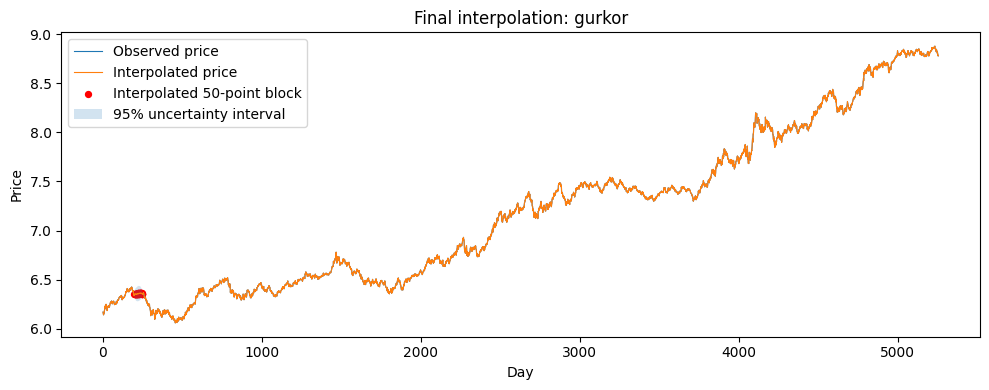

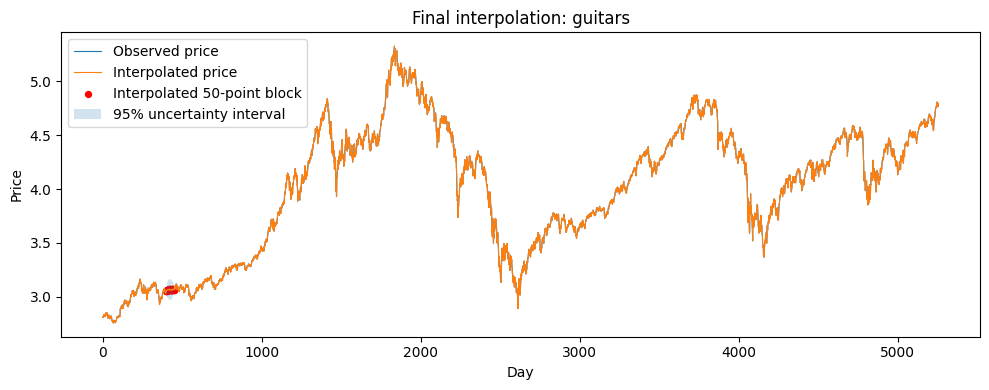

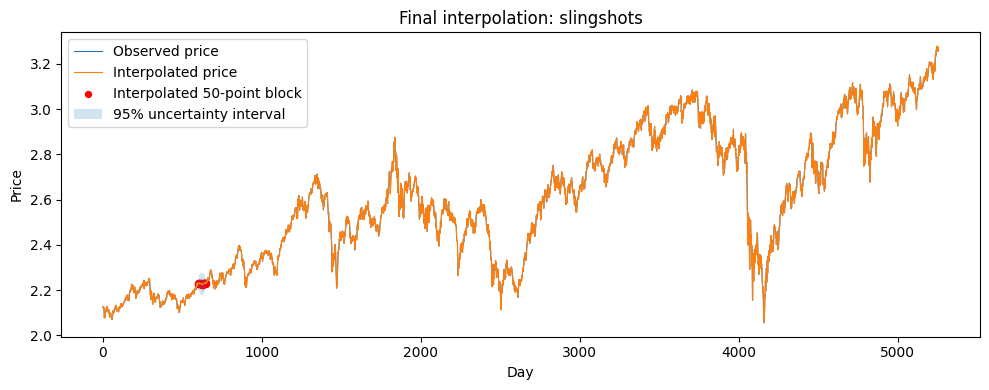

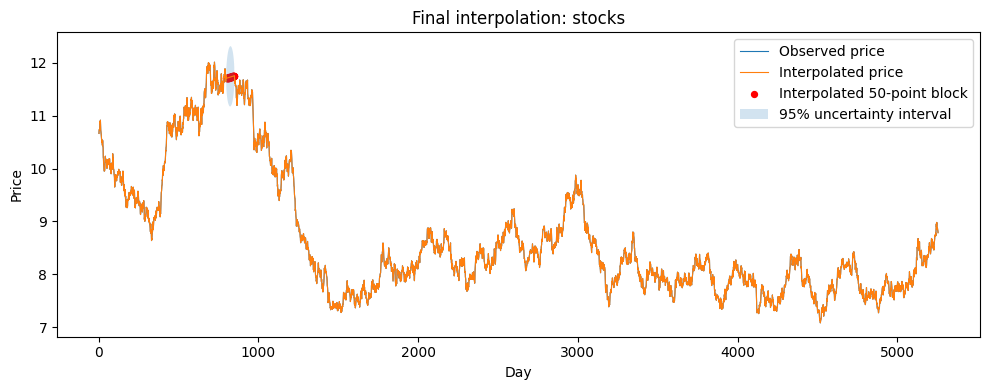

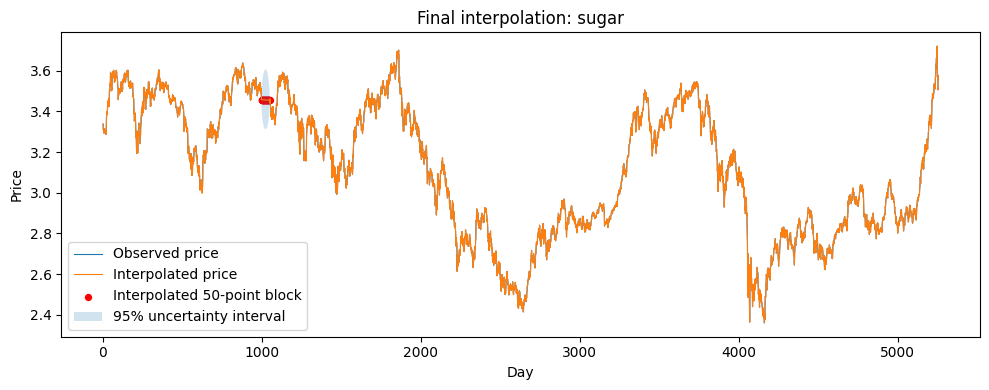

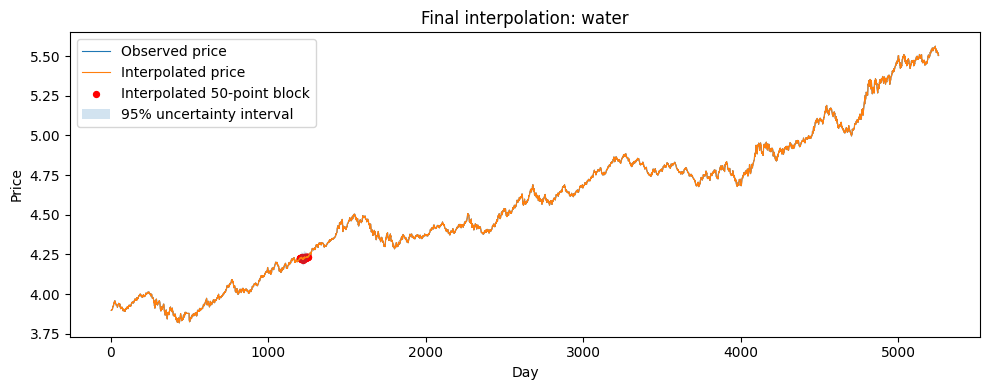

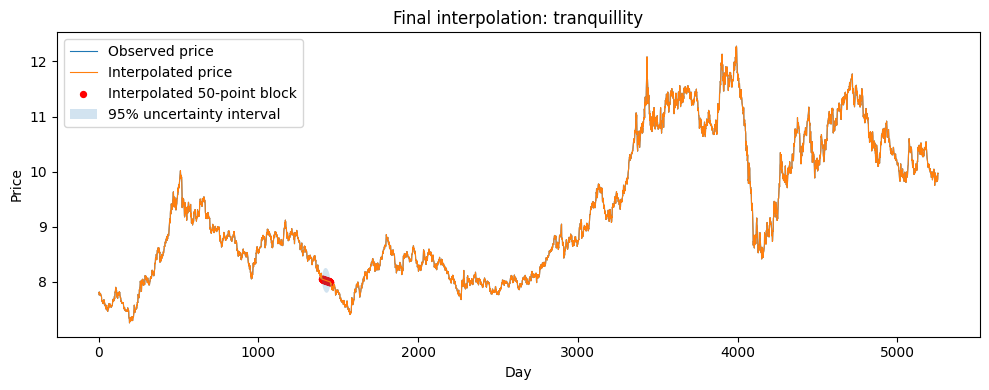

In [28]:
for col, result in final_interpolation_results.items():
    plot_interpolation_result(
        result=result,
        asset_name=col,
        title=f"Final interpolation: {col}",
        save_path=CHART_DIR / f"interpolation_{col}.png",
    )

In [29]:
def plot_zoomed_interpolations(
    interpolation_results: dict,
    window: int = 45,
    save_path: Path | None = None
):
    n_assets = len(interpolation_results)
    ncols = 2
    nrows = int(np.ceil(n_assets / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(12, 2.6 * nrows),
        sharex=False
    )

    axes = axes.flatten()

    for ax, (asset, result) in zip(axes, interpolation_results.items()):
        interpolated = result["is_interpolated"]
        interp_pos = np.where(interpolated.to_numpy())[0]

        if len(interp_pos) == 0:
            ax.set_title(f"{asset}: no interpolation")
            ax.axis("off")
            continue

        st = interp_pos.min()
        ed = interp_pos.max() + 1

        left = max(0, st - window)
        right = min(len(result), ed + window)

        zoom = result.iloc[left:right]
        zoom_interpolated = zoom["is_interpolated"]

        # Observed prices only outside the missing block
        observed_only = zoom["original"].copy()

        ax.plot(
            zoom.index,
            observed_only,
            linewidth=1.1,
            label="Observed price"
        )

        # Interpolated segment only
        ax.plot(
            zoom.index[zoom_interpolated],
            zoom.loc[zoom_interpolated, "filled"],
            linewidth=2.0,
            color="red",
            label="Interpolated block"
        )

        # Uncertainty interval only around the interpolated block
        ax.fill_between(
            zoom.index[zoom_interpolated],
            zoom.loc[zoom_interpolated, "lower_95"],
            zoom.loc[zoom_interpolated, "upper_95"],
            alpha=0.18,
            label="95% interval"
        )

        # Gap boundaries
        ax.axvline(result.index[st], linestyle="--", linewidth=0.8, alpha=0.6)
        ax.axvline(result.index[ed - 1], linestyle="--", linewidth=0.8, alpha=0.6)

        ax.set_title(asset, fontsize=11)
        ax.set_xlabel("Day", fontsize=9)
        ax.set_ylabel("Price", fontsize=9)
        ax.grid(alpha=0.25)
        ax.tick_params(axis="both", labelsize=8)

    for j in range(len(interpolation_results), len(axes)):
        axes[j].axis("off")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=3,
        frameon=True,
        fontsize=9,
        bbox_to_anchor=(0.5, 1.00)
    )

    fig.suptitle(
        "Zoomed view of interpolated missing blocks",
        fontsize=14,
        y=1.03
    )

    fig.tight_layout(rect=[0, 0, 1, 0.96])

    if save_path is not None:
        plt.savefig(save_path, dpi=250, bbox_inches="tight")

    plt.show()

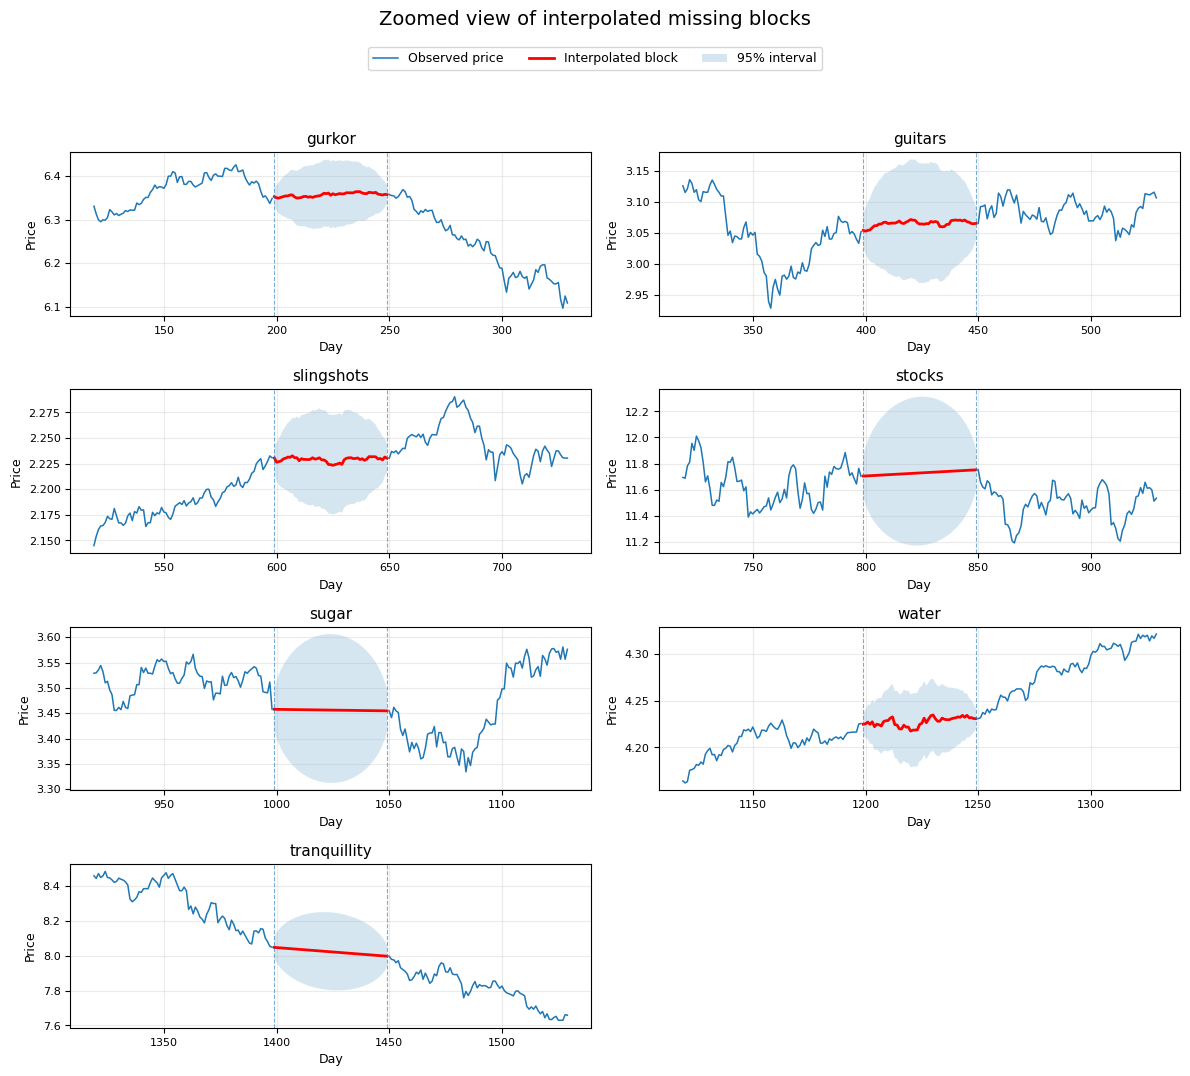

In [30]:
plot_zoomed_interpolations(
    final_interpolation_results,
    window=80,
    save_path=CHART_DIR / "zoomed_all_interpolations.png"
)